In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Load the dataset


In [3]:
df = pd.read_csv("creditcard_2023.csv")

In [4]:
df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


id: Unique identifier for each transaction.
V1-V28: Anonymized features representing various transaction attributes (e.g., time, location, etc.).
Amount: The transaction amount.
Class: Binary label indicating whether the transaction is fraudulent (1) or not (0).


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64
 21  V21     56

In [6]:
df.describe()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,568630.000000,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,5.686300e+05,5.686300e+05,568630.000000,5.686300e+05,568630.000000,...,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,568630.0
mean,284314.500000,-5.118237e-17,-5.118237e-17,1.023647e-16,0.000000,2.559118e-17,2.559118e-17,0.000000,1.279559e-17,0.000000,...,1.279559e-17,1.599449e-18,5.598072e-18,-2.559118e-17,-4.478457e-17,-6.397796e-18,-2.559118e-17,3.198898e-17,12041.957635,0.5
std,164149.486122,1.000001e+00,1.000001e+00,1.000001e+00,1.000001,1.000001e+00,1.000001e+00,1.000001,1.000001e+00,1.000001,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,6919.644449,0.5
min,0.000000,-3.495584e+00,-4.996657e+01,-3.183760e+00,-4.951222,-9.952786e+00,-2.111111e+01,-4.351839,-1.075634e+01,-3.751919,...,-1.938252e+01,-7.734798e+00,-3.029545e+01,-4.067968e+00,-1.361263e+01,-8.226969e+00,-1.049863e+01,-3.903524e+01,50.010000,0.0
25%,142157.250000,-5.652859e-01,-4.866777e-01,-6.492987e-01,-0.656020,-2.934955e-01,-4.458712e-01,-0.283533,-1.922572e-01,-0.568745,...,-1.664408e-01,-4.904892e-01,-2.376289e-01,-6.515801e-01,-5.541485e-01,-6.318948e-01,-3.049607e-01,-2.318783e-01,6054.892500,0.0
50%,284314.500000,-9.363846e-02,-1.358939e-01,3.528579e-04,-0.073762,8.108788e-02,7.871758e-02,0.233366,-1.145242e-01,0.092526,...,-3.743065e-02,-2.732881e-02,-5.968903e-02,1.590123e-02,-8.193162e-03,-1.189208e-02,-1.729111e-01,-1.392973e-02,12030.150000,0.5
75%,426471.750000,8.326582e-01,3.435552e-01,6.285380e-01,0.707005,4.397368e-01,4.977881e-01,0.525955,4.729905e-02,0.559262,...,1.479787e-01,4.638817e-01,1.557153e-01,7.007374e-01,5.500147e-01,6.728879e-01,3.340230e-01,4.095903e-01,18036.330000,1.0
max,568629.000000,2.229046e+00,4.361865e+00,1.412583e+01,3.201536,4.271689e+01,2.616840e+01,217.873038,5.958040e+00,20.270062,...,8.087080e+00,1.263251e+01,3.170763e+01,1.296564e+01,1.462151e+01,5.623285e+00,1.132311e+02,7.725594e+01,24039.930000,1.0


Exploratory Data Analysis (EDA)


In [7]:
df["Class"].value_counts()

Class
0    284315
1    284315
Name: count, dtype: int64

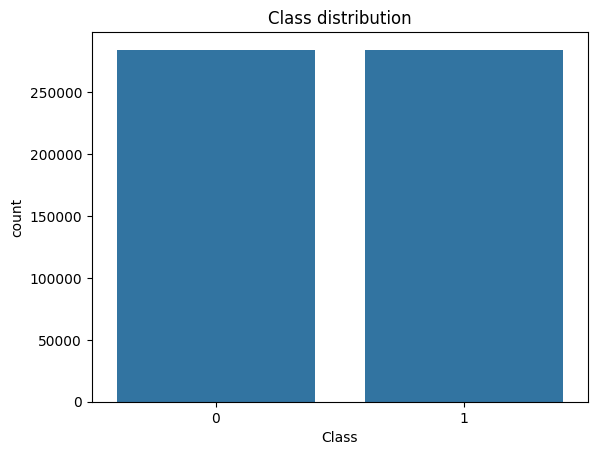

In [8]:
sns.countplot(x='Class', data=df)
plt.title("Class distribution")
plt.show()

In [9]:
# % of frauds to the total data

(df["Class"].value_counts()[1] / df.shape[0]) * 100

np.float64(50.0)

In [10]:
# check missing values

df.isnull().sum()

id        0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

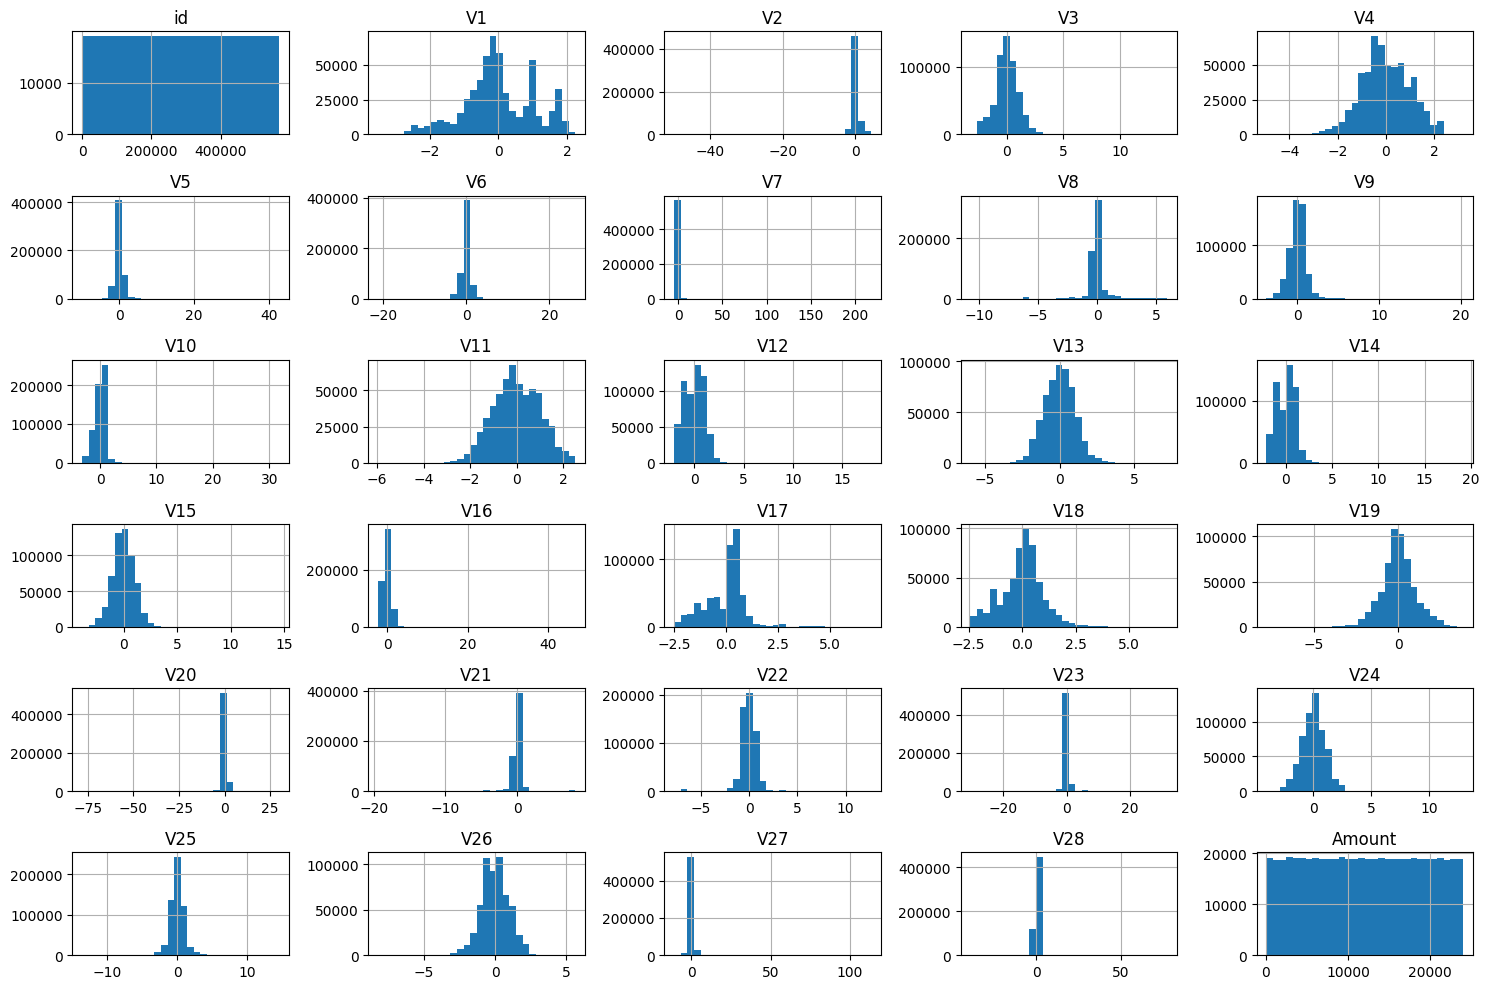

In [11]:
# Distribution of numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Class')
df[numeric_cols].hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()


In [12]:
df["Amount"].describe()

count    568630.000000
mean      12041.957635
std        6919.644449
min          50.010000
25%        6054.892500
50%       12030.150000
75%       18036.330000
max       24039.930000
Name: Amount, dtype: float64

Text(0.5, 1.0, 'Amount Distribution (log scale)')

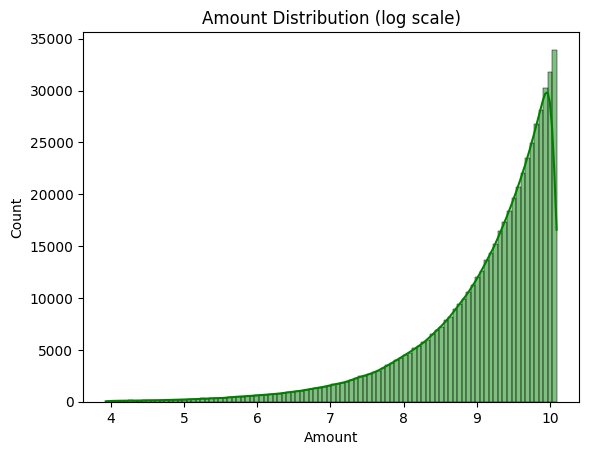

In [13]:
sns.histplot(np.log1p(df["Amount"]), bins = 100, kde = True, color= "green")
plt.title("Amount Distribution (log scale)")

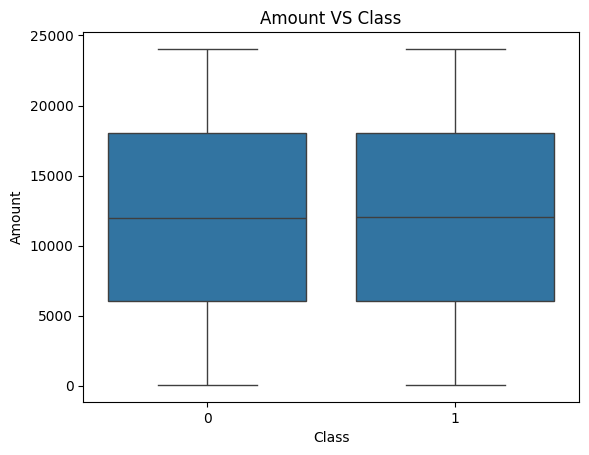

In [14]:
sns.boxplot(data= df[df["Amount"] < 25000], x = "Class", y = "Amount")
plt.title("Amount VS Class")
plt.show()

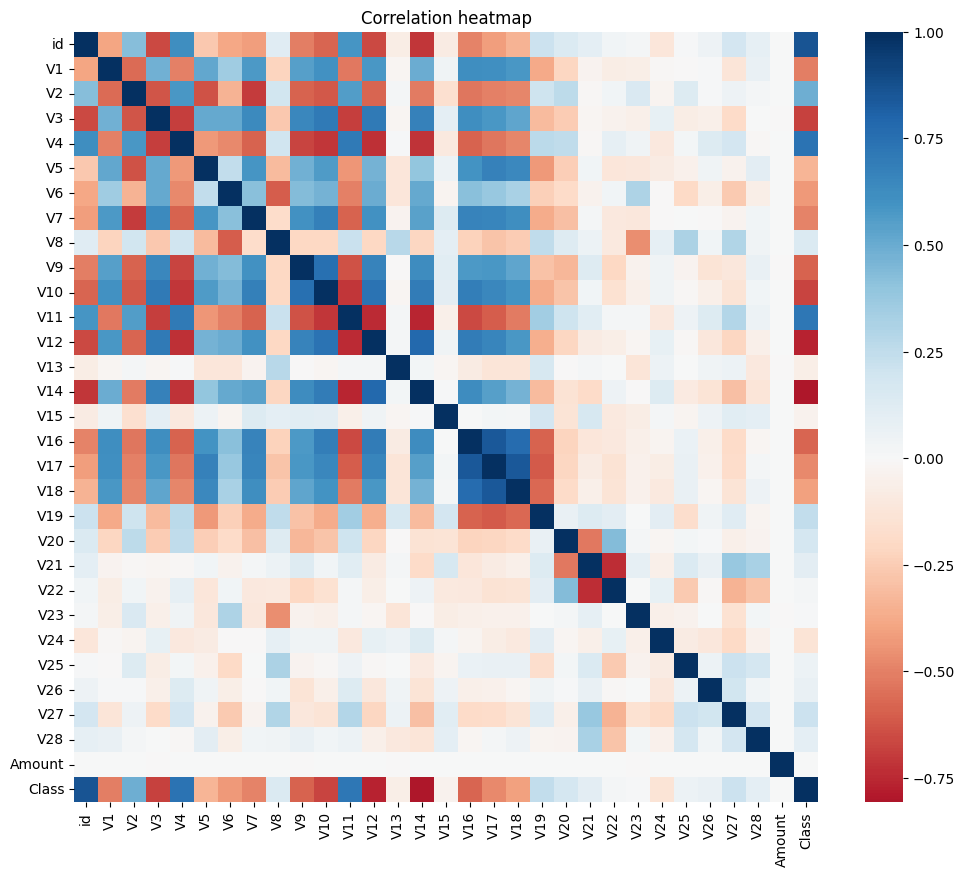

In [15]:
# Correlation heatmap

plt.figure(figsize = (12,10))
sns.heatmap(df.corr(), cmap="RdBu", center = 0)
plt.title("Correlation heatmap")
plt.show()

Data Cleaning


In [16]:
# Fill missing values with column median
df = df.fillna(df.median(numeric_only=True))

In [17]:
df.isnull().sum().sum()

np.int64(0)

In [18]:
df = df.drop(columns=['id'])

In [19]:
# check for dupicates
df.duplicated().sum()

np.int64(1)

In [20]:
df.shape

(568630, 30)

Preprocessing for modelling


In [21]:
#Split features and target

X = df.drop(columns=['Class'])
y = df['Class']

In [22]:
#Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print("Train set:", X_train.shape, y_train.value_counts())
print("Test set:", X_test.shape, y_test.value_counts())

Train set: (454904, 29) Class
0    227452
1    227452
Name: count, dtype: int64
Test set: (113726, 29) Class
1    56863
0    56863
Name: count, dtype: int64


In [23]:
#Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
# #Handle class imbalance

# smote = SMOTE(random_state=42)
# X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# print(y_train_res.value_counts())

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

In [26]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

In [27]:

classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight=class_weights
)
classifier.fit(X_train_scaled, y_train)
y_pred = classifier.predict(X_test_scaled)

Accuracy : 99.98%
recall : 1.00
precision : 1.00
f1 : 1.00


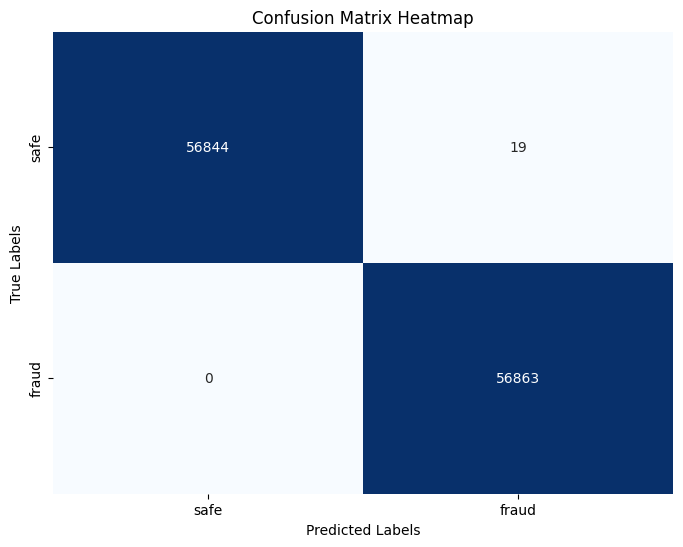

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy : {accuracy * 100:.2f}%')
print(f'recall : {recall:.2f}')
print(f'precision : {precision:.2f}')
print(f'f1 : {f1:.2f}')

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False, 
            xticklabels=("safe", "fraud"), yticklabels=("safe", "fraud"))

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [29]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


fraud_ratio = y_train.mean()

iso = IsolationForest(
    contamination = fraud_ratio,
    n_estimators=200,
    random_state=42
)

iso.fit(X_train_scaled)

y_pred_test = iso.predict(X_test_scaled)

y_pred_test = [1 if p == -1 else 0 for p in y_pred_test]

# Scores for ROC-AUC
scores_test = iso.decision_function(X_test_scaled)

# Evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))
print("ROC-AUC:", roc_auc_score(y_test, scores_test))

Confusion Matrix:
 [[35425 21438]
 [21370 35493]]

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.62      0.62     56863
           1       0.62      0.62      0.62     56863

    accuracy                           0.62    113726
   macro avg       0.62      0.62      0.62    113726
weighted avg       0.62      0.62      0.62    113726

ROC-AUC: 0.3186789416514795


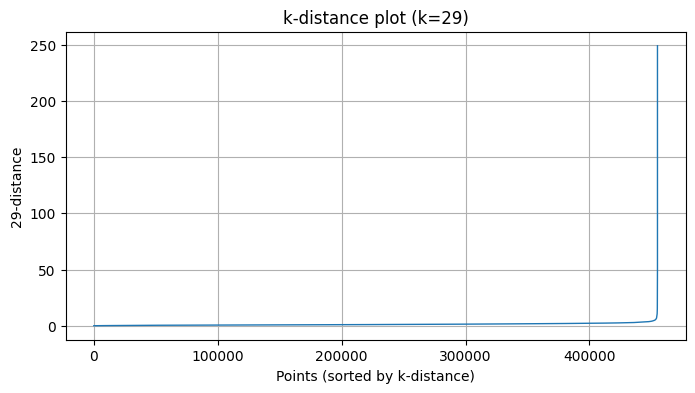

In [30]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

X = X_train_scaled

n_features = X.shape[1]

min_samples = max(5, n_features + 1)

k = min_samples - 1


nn = NearestNeighbors(n_neighbors=k + 1, algorithm='auto')
nn.fit(X)
distances, indices = nn.kneighbors(X)

k_distances = np.sort(distances[:, k])

plt.figure(figsize=(8, 4))
plt.plot(np.arange(len(k_distances)), k_distances, linewidth=1)
plt.xlabel('Points (sorted by k-distance)')
plt.ylabel(f'{k}-distance')
plt.title(f'k-distance plot (k={k})')
plt.grid(True)

In [31]:
first_deriv = np.diff(k_distances)
second_deriv = np.diff(first_deriv)

if len(second_deriv) > 0:
    knee_idx = np.argmax(np.abs(second_deriv)) + 1
    suggested_eps = k_distances[knee_idx]
else:
    suggested_eps = None


print("Suggested eps (heuristic):", suggested_eps)
print("k (min_samples-1) =", k)

Suggested eps (heuristic): 88.20144431063582
k (min_samples-1) = 29


In [ ]:
# If eps was successfully detected
if suggested_eps is not None:
    dbscan = DBSCAN(
        eps=suggested_eps,
        min_samples=min_samples,
        metric='euclidean'
    )

    labels = dbscan.fit_predict(X)

else:
    print("No eps detected — try manually setting eps.")


In [ ]:
# Number of clusters (excluding noise)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Number of noise points
n_noise = np.sum(labels == -1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)


In [ ]:
if n_clusters > 1:
    sil_score = silhouette_score(X, labels)
    print("Silhouette Score:", sil_score)
else:
    print("Silhouette Score not defined (need at least 2 clusters).")
